# Run drop particles analysis

In [71]:
import os
from pathlib import Path
from dna_linker import dna_linkers as dnal
from dna_linker import run_pipeline as run
from dna_linker import config
from cryocat import cryomotl
import numpy as np
import pandas as pd


from pathlib import Path
from tqdm import tqdm

from itertools import combinations

import itertools as it

In [9]:
# ────────────────────────────────────────────────────────────────────────────────
# connectivity utilities
# ────────────────────────────────────────────────────────────────────────────────
from typing import Set, Dict, Tuple, List

Edge    = Tuple[int, int, str]                                    # (i, j, type)
ConnDic = Dict[int, List[Tuple[int, float, str]]]                 # {node:[…]}


# Functions

In [10]:
def connectivity_to_edge_set(conn_dict):
    """
    Converts a connectivity dictionary of the form
      {node: [(neighbor, prob, type), ...], ...}
    into a set of undirected edges (node1, node2, type) with node1 < node2.
    """
    edges = set()
    for node, neighbors in conn_dict.items():
        for neighbor, _, edge_type in neighbors:
            i, j = sorted((node, neighbor))
            edges.add((i, j, edge_type))
    return edges


def compute_f1_from_connectivity(
    truth_conn: ConnDic,
    pred_conn : ConnDic,
    ignore_nodes: Set[int] = frozenset()
):
    """
    Computes precision, recall, and F1-score between ground-truth
    and predicted connectivity dictionaries.

    Parameters:
        truth_conn (dict): Ground truth connectivity:
            {node: [(neighbor, prob, type), ...], ...}
        pred_conn (dict): Predicted connectivity, same format.
        
        Any edge that touches a node in `ignore_nodes`
    is removed **from both reference and prediction** prior to scoring.

    Returns:
        precision (float), recall (float), f1_score (float)
    """
    
    # convert → edge sets
    truth_edges = connectivity_to_edge_set(truth_conn)
    pred_edges  = connectivity_to_edge_set(pred_conn)

    if ignore_nodes:
        truth_edges = {
            e for e in truth_edges if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }
        pred_edges = {
            e for e in pred_edges  if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }

    # TP / FP / FN
    tp = len(truth_edges & pred_edges)
    fp = len(pred_edges - truth_edges)
    fn = len(truth_edges - pred_edges)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return precision, recall, f1

def add_noise_to_motl(
    motl: cryomotl.Motl,
    pos_sigma: float,
    ang_sigma_deg: float,
    output_filename:str,
    seed: int = None
) -> cryomotl.Motl:
    """
    Returns a copy of `motl` where each particle has independent Gaussian
    noise added to (x,y,z) and (phi,psi,theta).

    Parameters:
        motl: a cryomotl.Motl instance.
        pos_sigma: standard deviation for positional noise (same units as x,y,z).
        ang_sigma_deg: standard deviation for angular noise (degrees).
        seed: optional random seed.

    Returns:
        new_motl: a fresh cryomotl.Motl with motl.df modified.
    """
    df = motl.df.copy()
    rng = np.random.default_rng(seed)

    # add to x,y,z shifts
    for coord in ("x", "y", "z"):
        df[coord] = df[coord] + rng.normal(0, pos_sigma, size=len(df))
    # add to Euler angles
    for ang in ("phi", "psi", "theta"):
        df[ang] = df[ang] + rng.normal(0, ang_sigma_deg, size=len(df))

    # create a new EmMotl object from this DF
    new = cryomotl.Motl(motl_df=df)
    new.write_out(output_filename)
    return new, output_filename


def remove_by_subtomo_id(motl, ids_to_remove, out_path):
    df = motl.df.copy()
    if "subtomo_id" not in df.columns:
        raise KeyError("subtomo_id column not present; call motl_stamp_subtomo_id_from_index first.")
    keep = ~df["subtomo_id"].isin(set(ids_to_remove))
    df = df.loc[keep].reset_index(drop=True)   # index is irrelevant now
    new = cryomotl.Motl(motl_df=df)
    new.write_out(out_path)
    return new





# Run drop - analysis

In [47]:
# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')
motl0.df

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()
PARTICLE_IDS

for missing in PARTICLES:
    suffix = f'dropped_sid{missing}'
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'

    # 1) drop by subtomo_id
    a=remove_by_subtomo_id(motl0, {missing}, motl_used_path)
    #print(a.df)
    

In [13]:
%%time

PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=1.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for missing in PARTICLES:
    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    suffix = f'dropped_sid{missing}'
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, {missing}, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
        Path(p).mkdir(parents=True, exist_ok=True)
    
    # 3-c) Run the pipeline ----------------------------------------
    run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
            )
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )

    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict,
            ignore_nodes={missing}
    )

    records.append({
            'missing_id': missing,
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


The file:  ./outputs/outputs_EMD2601_dropped_sid0/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid1/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid2/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
The fil

In [15]:
records

[{'missing_id': 0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 {'missing_id': 1,
  'precision': 0.3333333333333333,
  'recall': 0.3,
  'f1': 0.3157894736842105},
 {'missing_id': 2,
  'precision': 0.2222222222222222,
  'recall': 0.2,
  'f1': 0.2105263157894737},
 {'missing_id': 3,
  'precision': 0.4444444444444444,
  'recall': 0.4,
  'f1': 0.4210526315789474},
 {'missing_id': 4, 'precision': 0.5, 'recall': 0.4, 'f1': 0.4444444444444445},
 {'missing_id': 5,
  'precision': 0.3333333333333333,
  'recall': 0.3,
  'f1': 0.3157894736842105},
 {'missing_id': 6,
  'precision': 0.2222222222222222,
  'recall': 0.2,
  'f1': 0.2105263157894737},
 {'missing_id': 7,
  'precision': 0.3333333333333333,
  'recall': 0.3,
  'f1': 0.3157894736842105},
 {'missing_id': 8,
  'precision': 0.2222222222222222,
  'recall': 0.2,
  'f1': 0.2105263157894737},
 {'missing_id': 9, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 {'missing_id': 10,
  'precision': 0.3333333333333333,
  'recall': 0.3,
  'f1': 0.31578947368

## Remove 2 particles at a time 

In [19]:
%%time


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))




PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=2.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for pair in combinations(PARTICLES, int(n_removals)):


    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    ignore_set = set(pair)
    suffix     = combo_suffix(pair)
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
        Path(p).mkdir(parents=True, exist_ok=True)
    
    # 3-c) Run the pipeline ----------------------------------------
    run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
            )
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )

    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict,
            ignore_nodes={missing}
    )

    records.append({
            'missing_id': missing,
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


The file:  ./outputs/outputs_EMD2601_dropped_sid0_1/clusters_20nm/motl_tomo0.0_cluster10.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 10.0
Figure(640x480)
(10, 10, 4)
Largest connected component: {0, 1, 3, 5, 6, 7, 8, 9}
Size of largest connected component: 8
{0, 1, 3, 5, 6, 7, 8, 9}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid0_2/clusters_20nm/motl_tomo0.0_cluster10.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 10.0
Figure(640x480)
(10, 10, 4)
Largest connected component: {0, 2, 4, 5, 6, 7, 8, 9}
Size of largest connected component: 8
{0, 2, 4, 5, 6, 7, 8, 9}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid0_3/clusters_20nm/motl_tomo0.0_cluster10.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 10.0
Figure(640x480)
(10, 10, 4)
Largest connected component: {0, 1, 2, 4, 5, 7, 8, 9}
Size of largest connected component: 8
{0, 1, 2, 4, 5, 7, 8, 9}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_s

In [20]:
records

[{'missing_id': 11,
  'precision': 0.1111111111111111,
  'recall': 0.1,
  'f1': 0.10526315789473685},
 {'missing_id': 11,
  'precision': 0.2222222222222222,
  'recall': 0.2,
  'f1': 0.2105263157894737},
 {'missing_id': 11,
  'precision': 0.11764705882352941,
  'recall': 0.1,
  'f1': 0.1081081081081081},
 {'missing_id': 11,
  'precision': 0.1,
  'recall': 0.1,
  'f1': 0.10000000000000002},
 {'missing_id': 11,
  'precision': 0.1111111111111111,
  'recall': 0.1,
  'f1': 0.10526315789473685},
 {'missing_id': 11, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 {'missing_id': 11,
  'precision': 0.2,
  'recall': 0.2,
  'f1': 0.20000000000000004},
 {'missing_id': 11,
  'precision': 0.2,
  'recall': 0.2,
  'f1': 0.20000000000000004},
 {'missing_id': 11, 'precision': 0.3, 'recall': 0.3, 'f1': 0.3},
 {'missing_id': 11,
  'precision': 0.2,
  'recall': 0.2,
  'f1': 0.20000000000000004},
 {'missing_id': 11,
  'precision': 0.2,
  'recall': 0.2,
  'f1': 0.20000000000000004},
 {'missing_id': 11,
  'preci

# Removal of 3 particles

In [21]:
%%time


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))




PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=3.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for pair in combinations(PARTICLES, int(n_removals)):


    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    ignore_set = set(pair)
    suffix     = combo_suffix(pair)
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
        Path(p).mkdir(parents=True, exist_ok=True)
    
    # 3-c) Run the pipeline ----------------------------------------
    run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
            )
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )

    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict,
            ignore_nodes={missing}
    )

    records.append({
            'missing_id': missing,§
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


The file:  ./outputs/outputs_EMD2601_dropped_sid0_1_2/clusters_20nm/motl_tomo0.0_cluster9.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 9.0
Figure(640x480)
(9, 9, 4)
Largest connected component: {0, 1, 2, 3, 4, 5}
Size of largest connected component: 6
{0, 1, 2, 3, 4, 5}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid0_1_3/clusters_20nm/motl_tomo0.0_cluster9.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 9.0
Figure(640x480)
(9, 9, 4)
Largest connected component: {0, 1, 3, 6, 7, 8}
Size of largest connected component: 6
{0, 1, 3, 6, 7, 8}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid0_1_4/clusters_20nm/motl_tomo0.0_cluster9.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 9.0
Figure(640x480)
(9, 9, 4)
Largest connected component: {0, 1, 3, 5, 6}
Size of largest connected component: 5
{0, 1, 3, 5, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_dropped_sid0_1_5/clusters_20nm/motl_tomo0.0_cluster9.0.em

In [87]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def build_index_map_by_xyz(motl_old, motl_new, *, max_dist=None):
    """
    Returns:
      new_to_old : {new_index_label -> old_index_label}
      removed_old: set of old index labels that are not present in motl_new
      match_costs: np.array of per-matched Euclidean distances (same units as x,y,z)
    """
    df_old = motl_old.df
    df_new = motl_new.df

    old_idx = df_old.index.to_numpy()
    new_idx = df_new.index.to_numpy()

    old_xyz = df_old[['x','y','z']].to_numpy(dtype=float)
    new_xyz = df_new[['x','y','z']].to_numpy(dtype=float)

    # cost matrix (n_new x n_old): Euclidean distance
    D = np.linalg.norm(new_xyz[:, None, :] - old_xyz[None, :, :], axis=2)

    # Hungarian assignment: covers min(n_new, n_old) pairs
    row_ind, col_ind = linear_sum_assignment(D)
    costs = D[row_ind, col_ind]

    # Optional gate: drop suspicious matches (too far)
    new_to_old = {}
    for r, c, d in zip(row_ind, col_ind, costs):
        if (max_dist is None) or (d <= max_dist):
            new_to_old[int(new_idx[r])] = int(old_idx[c])

    removed_old = set(map(int, old_idx)) - set(new_to_old.values())
    match_costs = np.array([D[row_ind[i], col_ind[i]] for i in range(len(row_ind))
                            if int(new_idx[row_ind[i]]) in new_to_old])

    return new_to_old, removed_old, match_costs


In [88]:
def relabel_conn_indices_to_old(conn_new_idx, new_to_old):
    out = {}
    for node_new, nbrs in conn_new_idx.items():
        if node_new not in new_to_old:     # unmapped -> drop
            continue
        node_old = new_to_old[node_new]
        for (nbr_new, p, t) in nbrs:
            if nbr_new not in new_to_old:
                continue
            nbr_old = new_to_old[nbr_new]
            out.setdefault(node_old, []).append((nbr_old, p, t))
    return out


In [89]:
# Build mapping new indices -> old indices based on positions
new_to_old, removed_old, costs = build_index_map_by_xyz(motl_old=motl0,
                       motl_new=motl_after, )

# Renumbering dictionary for scores

In [90]:
%%time


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))




PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=1.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records_single = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for pair in combinations(PARTICLES, int(n_removals)):


    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    ignore_set = set(pair)
    suffix     = combo_suffix(pair)
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    # Build mapping new indices -> old indices based on positions
    motl_new=cryomotl.EmMotl(f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/motl_tomo0.0_cluster{n_remain}.em')
    new_to_old, removed_old, costs = build_index_map_by_xyz(
                                        motl_old=motl0,      # original, before any dropping
                                        motl_new= motl_new,
    max_dist=None        # or set to e.g. 3 * pos_sigma
    )

    
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict_new = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )
    # Relabel prediction to OLD index space
    pred_dict_old = relabel_conn_indices_to_old(pred_dict_new, new_to_old)


    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict_old,
            ignore_nodes=pair
    )

    records_single.append({
            'missing_id': pair,
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


CPU times: user 37.8 ms, sys: 12.5 ms, total: 50.3 ms
Wall time: 92.3 ms


In [91]:
records_single

[{'missing_id': (0,),
  'precision': 0.9090909090909091,
  'recall': 1.0,
  'f1': 0.9523809523809523},
 {'missing_id': (1,),
  'precision': 0.7272727272727273,
  'recall': 0.8,
  'f1': 0.761904761904762},
 {'missing_id': (2,),
  'precision': 0.7272727272727273,
  'recall': 0.8,
  'f1': 0.761904761904762},
 {'missing_id': (3,),
  'precision': 0.7272727272727273,
  'recall': 0.8,
  'f1': 0.761904761904762},
 {'missing_id': (4,), 'precision': 0.9, 'recall': 0.9, 'f1': 0.9},
 {'missing_id': (5,),
  'precision': 0.9090909090909091,
  'recall': 1.0,
  'f1': 0.9523809523809523},
 {'missing_id': (6,),
  'precision': 0.9090909090909091,
  'recall': 1.0,
  'f1': 0.9523809523809523},
 {'missing_id': (7,),
  'precision': 0.8181818181818182,
  'recall': 0.9,
  'f1': 0.8571428571428572},
 {'missing_id': (8,),
  'precision': 0.8181818181818182,
  'recall': 0.9,
  'f1': 0.8571428571428572},
 {'missing_id': (9,),
  'precision': 0.8181818181818182,
  'recall': 0.9,
  'f1': 0.8571428571428572},
 {'missin

In [59]:
%%time


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))




PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=2.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records_pair = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for pair in combinations(PARTICLES, int(n_removals)):


    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    ignore_set = set(pair)
    suffix     = combo_suffix(pair)
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    # Build mapping new indices -> old indices based on positions
    motl_new=cryomotl.EmMotl(f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/motl_tomo0.0_cluster{n_remain}.em')
    new_to_old, removed_old, costs = build_index_map_by_xyz(
                                        motl_old=motl0,      # original, before any dropping
                                        motl_new= motl_new,
    max_dist=None        # or set to e.g. 3 * pos_sigma
    )

    
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict_new = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )
    # Relabel prediction to OLD index space
    pred_dict_old = relabel_conn_indices_to_old(pred_dict_new, new_to_old)


    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict_old,
            ignore_nodes=pair
    )

    records_pair.append({
            'missing_id': pair,
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


CPU times: user 117 ms, sys: 29.9 ms, total: 147 ms
Wall time: 262 ms


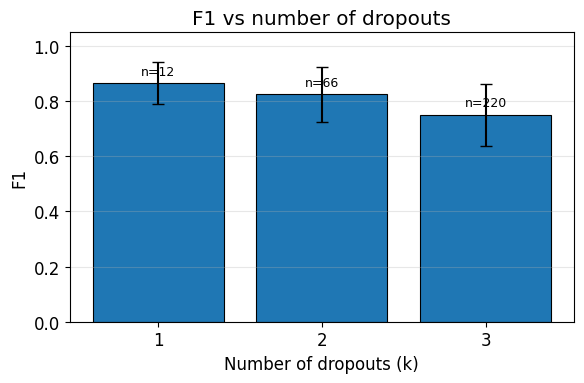

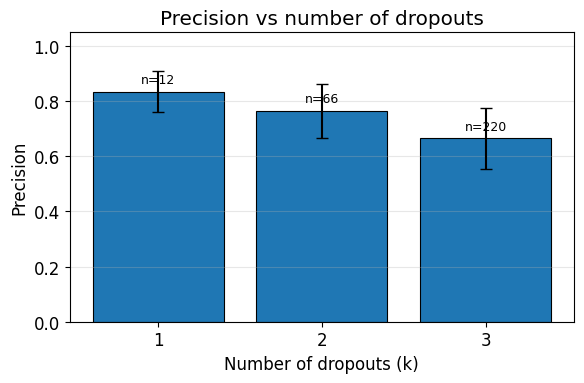

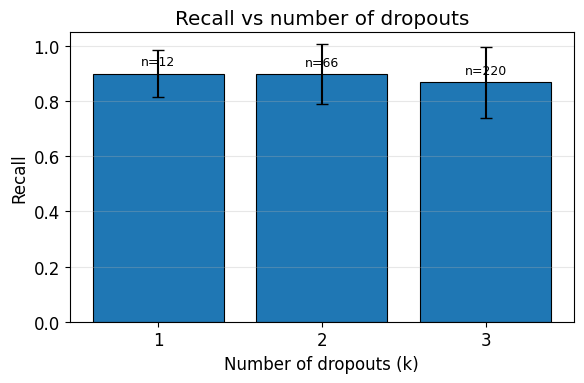

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Expect these to exist:
# records_single, records_pair, records_three
# each like: {'missing_id': (0,1), 'precision': ..., 'recall': ..., 'f1': ...}

def _stats(records, metric):
    if not records:
        return np.nan, 0.0, 0
    s = pd.DataFrame(records)[metric].astype(float).dropna()
    if s.empty:
        return np.nan, 0.0, 0
    mean = s.mean()
    std  = s.std(ddof=1) if len(s) > 1 else 0.0
    return float(mean), float(std), int(len(s))

def _plot_metric(k_vals, means, stds, ns, metric_label):
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(k_vals))
    bars = ax.bar(x, means, yerr=stds, capsize=4, edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in k_vals])
    ax.set_xlabel('Number of dropouts (k)')
    ax.set_ylabel(metric_label)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{metric_label} vs number of dropouts')
    ax.grid(axis='y', alpha=0.3)

    # annotate n above bars
    for xi, (b, n) in enumerate(zip(bars, ns)):
        h = b.get_height()
        ax.text(xi, min(1.02, h + 0.02), f'n={n}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# ---- aggregate per k ----
k_vals = [1, 2, 3]
lists  = [records_single, records_pair, records_three]

f1_mean, f1_std, f1_n = zip(*[_stats(L, 'f1')        for L in lists])
pr_mean, pr_std, pr_n = zip(*[_stats(L, 'precision') for L in lists])
rc_mean, rc_std, rc_n = zip(*[_stats(L, 'recall')    for L in lists])

# ---- plots: one figure per metric ----
_plot_metric(k_vals, f1_mean, f1_std, f1_n, 'F1')
_plot_metric(k_vals, pr_mean, pr_std, pr_n, 'Precision')
_plot_metric(k_vals, rc_mean, rc_std, rc_n, 'Recall')


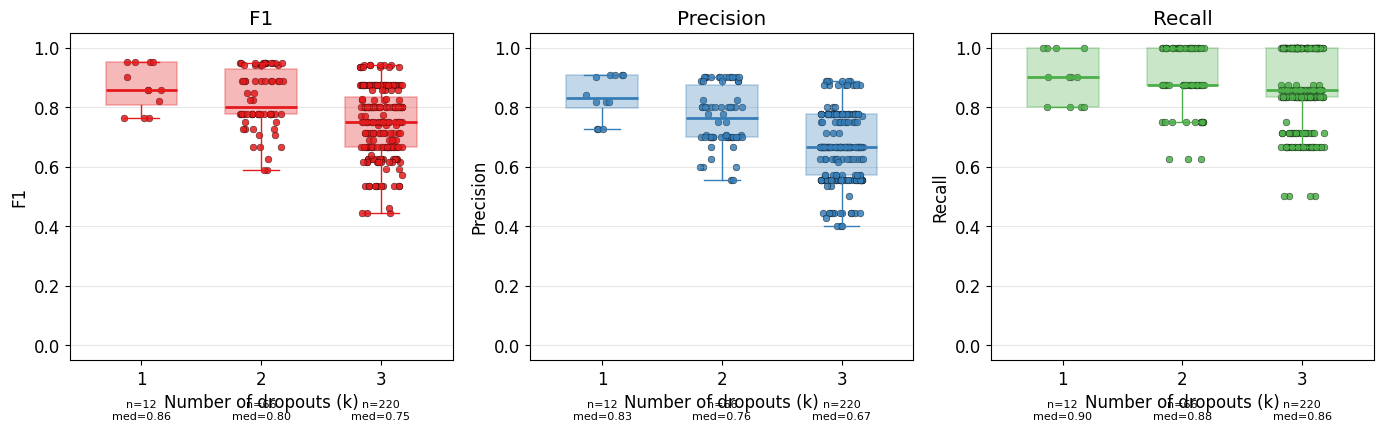

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# expects:
# records_single, records_pair, records_three
# each element: {'missing_id': (...), 'precision': float, 'recall': float, 'f1': float}

def collect_by_k(records_single, records_pair, records_three, metric):
    groups = {1: [], 2: [], 3: []}
    for rec in records_single:
        v = rec.get(metric, None)
        if v is not None: groups[1].append(float(v))
    for rec in records_pair:
        v = rec.get(metric, None)
        if v is not None: groups[2].append(float(v))
    for rec in records_three:
        v = rec.get(metric, None)
        if v is not None: groups[3].append(float(v))
    return groups

ORDER_K = [1, 2, 3]
jitter  = 0.18

metrics = [
    ('f1',        '#e41a1c', 'F1'),
    ('precision', '#377eb8', 'Precision'),
    ('recall',    '#4daf4a', 'Recall'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.25)

for ax, (metric, color, label) in zip(axes, metrics):
    groups = collect_by_k(records_single, records_pair, records_three, metric)

    for k in ORDER_K:
        ys = np.asarray(groups.get(k, []), float)
        if ys.size == 0:
            continue

        # box
        ax.boxplot(
            ys, positions=[k], widths=0.6, showfliers=False, patch_artist=True,
            boxprops    = dict(facecolor=color, edgecolor=color, linewidth=1.2, alpha=.3),
            medianprops = dict(color=color, linewidth=2),
            whiskerprops= dict(color=color),
            capprops    = dict(color=color),
        )

        # jittered points
        xs = k + np.random.uniform(-jitter, jitter, size=ys.size)
        ax.scatter(xs, ys, s=24, color=color, edgecolor='k', linewidth=0.3, alpha=0.85)

        # annotate n and median under each box (like your example)
        txt = f"n={ys.size}\nmed={np.median(ys):.2f}"
        ax.text(k, -0.12, txt, ha='center', va='top',
                transform=ax.get_xaxis_transform(), fontsize=8)

    ax.set_title(label)
    ax.set_xlabel('Number of dropouts (k)')
    ax.set_ylabel(label)
    ax.set_xticks(ORDER_K)
    ax.set_ylim(-.05, 1.05)
    ax.set_xlim(0.4, 3.6)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Pairs removals

In [52]:
%%time


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))




PARTICLE_IDS   = list(range(1, 14))           # or motl.df['subtomo_id'].unique()
N_TRIALS       = 1                           # number of trials
POS_SIGMAS     = np.array([0])                # ← no positional noise here; keep existing
ANG_SIGMA_DEG  = np.array([0])
EMD_ID        = 2601  

n_removals=3.0
n_remain = 12.0 - n_removals
# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**


records_three = []

# 0) prepare canonical MOTL once (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

# indices used by GT are now exactly the subtomo_id values
PARTICLES = motl0.df["subtomo_id"].tolist()

for pair in combinations(PARTICLES, int(n_removals)):


    # 0) prepare canonical MOTL once (subtomo_id == original index)
    motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
    motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

    # ------------------------------------------------------------------
    # 1  prepare MOTL without this particle
    ignore_set = set(pair)
    suffix     = combo_suffix(pair)
    motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
    
    # Drop by subtomo_id
    remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
    # ------------------------------------------------------------------
    # 2 run the full pipeline exactly as before
    path_mask = './inputs_dropped/'
    
    path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
    motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
    ...  # build other paths just like in your current script
    motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

    output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
    output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
    output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
        
    # Build mapping new indices -> old indices based on positions
    motl_new=cryomotl.EmMotl(f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/motl_tomo0.0_cluster{n_remain}.em')
    new_to_old, removed_old, costs = build_index_map_by_xyz(
                                        motl_old=motl0,      # original, before any dropping
                                        motl_new= motl_new,
    max_dist=None        # or set to e.g. 3 * pos_sigma
    )

    
    # ------------------------------------------------------------------
    # 3 load connectivity dictionaries
    pred_dict_new = pd.read_pickle(
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
    )
    # Relabel prediction to OLD index space
    pred_dict_old = relabel_conn_indices_to_old(pred_dict_new, new_to_old)


    # ------------------------------------------------------------------
    # 4  score with the new helper
    prec, rec, f1 = compute_f1_from_connectivity(
            truth_conn = GT_DICT,
            pred_conn  = pred_dict_old,
            ignore_nodes=pair
    )

    records_three.append({
            'missing_id': pair,
            'precision' : prec,
            'recall'    : rec,
            'f1'        : f1
    })


CPU times: user 633 ms, sys: 174 ms, total: 807 ms
Wall time: 1.75 s


In [53]:
records_three

[{'missing_id': 11,
  'precision': 0.5555555555555556,
  'recall': 0.8333333333333334,
  'f1': 0.6666666666666667},
 {'missing_id': 11, 'precision': 0.4, 'recall': 0.5, 'f1': 0.4444444444444445},
 {'missing_id': 11,
  'precision': 0.4444444444444444,
  'recall': 0.6666666666666666,
  'f1': 0.5333333333333333},
 {'missing_id': 11,
  'precision': 0.625,
  'recall': 0.8333333333333334,
  'f1': 0.7142857142857143},
 {'missing_id': 11,
  'precision': 0.5555555555555556,
  'recall': 0.8333333333333334,
  'f1': 0.6666666666666667},
 {'missing_id': 11,
  'precision': 0.5555555555555556,
  'recall': 0.8333333333333334,
  'f1': 0.6666666666666667},
 {'missing_id': 11, 'precision': 0.6666666666666666, 'recall': 1.0, 'f1': 0.8},
 {'missing_id': 11,
  'precision': 0.7777777777777778,
  'recall': 1.0,
  'f1': 0.8750000000000001},
 {'missing_id': 11,
  'precision': 0.8888888888888888,
  'recall': 1.0,
  'f1': 0.9411764705882353},
 {'missing_id': 11,
  'precision': 0.6666666666666666,
  'recall': 0.85

# Test: Removal of 4,5,6 particles

(0, 1, 2, 3)
(1, 4, 5, 6)
(3, 4, 6, 9)
(4, 6, 9, 10)
(3, 4, 6, 10)
(0, 4, 6, 11)
(2, 7, 9, 11)
(0, 1, 2, 10)
(1, 3, 6, 9)
(4, 5, 7, 10)
(5, 6, 7, 10)
(0, 1, 3, 6)
(1, 2, 3, 11)
(1, 6, 7, 8)
(3, 4, 9, 10)
(0, 1, 3, 10)
(4, 5, 8, 10)
(2, 3, 5, 10)
(1, 4, 5, 8)
(1, 5, 7, 9)
(2, 3, 6, 8)
(0, 8, 10, 11)
(4, 5, 10, 11)
(1, 6, 7, 11)
(0, 4, 5, 11)
(0, 1, 5, 7)
(0, 1, 5, 8)
(5, 7, 9, 10)
(0, 1, 5, 10)
(3, 9, 10, 11)
(5, 7, 8, 9)
(2, 3, 4, 9)
(0, 1, 6, 9)
(2, 5, 8, 11)
(0, 4, 5, 6)
(2, 5, 8, 10)
(0, 4, 7, 8)
(1, 4, 5, 11)
(2, 5, 7, 8)
(3, 6, 9, 11)
(0, 1, 8, 10)
(0, 5, 6, 8)
(0, 1, 9, 10)
(0, 4, 5, 7)
(0, 9, 10, 11)
(1, 3, 6, 10)
(2, 7, 8, 10)
(5, 7, 9, 11)
(7, 8, 9, 11)
(1, 2, 8, 9)
(1, 4, 5, 9)
(3, 5, 9, 10)
(4, 5, 7, 8)
(0, 2, 4, 5)
(2, 8, 10, 11)
(0, 4, 8, 9)
(0, 4, 7, 10)
(4, 6, 8, 10)
(3, 6, 8, 11)
(1, 2, 7, 11)
(0, 2, 5, 6)
(3, 5, 6, 8)
(6, 7, 9, 11)
(1, 3, 5, 10)
(2, 4, 5, 7)
(0, 4, 5, 8)
(0, 2, 6, 7)
(1, 2, 5, 8)
(4, 5, 7, 11)
(3, 7, 10, 11)
(1, 5, 7, 10)
(2, 3, 6, 10)
(1, 7, 9, 11)
(2

In [4]:
%%time
# -------------------------------------------------------------
# config
# -------------------------------------------------------------
N_SAMPLES_PER_K = 10           # ← sample size per k (4,5,6)
N_TRIALS        = 1
PIPELINE_BASE   = 1
EMD_ID          = 2601

GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)

# Canonical MOTL (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

PARTICLES = list(map(int, motl0.df["subtomo_id"].tolist()))
INPUTS_DIR = Path('inputs_dropped'); INPUTS_DIR.mkdir(parents=True, exist_ok=True)
# -------------------------------------------------------------
# main loop over k = 4,5,6
# -------------------------------------------------------------
for n_removals in range(1, 6):
    records = []
    n_remain = len(PARTICLES) - n_removals
    n_remain=float(n_remain)
    # sample 100 unique combinations of size n_removals
    sampled = sample_combinations(PARTICLES, n_removals, N_SAMPLES_PER_K, seed=123 + n_removals)

    for combo in sampled:
        print (combo)
        # 0) prepare canonical MOTL once (subtomo_id == original index)
        motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
        motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')
    
        # ------------------------------------------------------------------
        # 1  prepare MOTL without this particle
        ignore_set = set(combo)
        suffix     = combo_suffix(combo)
        motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
        # Drop by subtomo_id
        remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
        # ------------------------------------------------------------------
        # 2 run the full pipeline exactly as before
        path_mask = './inputs_dropped/'
        
        path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
        motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
        ...  # build other paths just like in your current script
        motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'
    
        output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
        output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
        output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
            
        for p in [path_output, output_path_cluster,
                      output_path_linker, output_path_dictionary]:
            Path(p).mkdir(parents=True, exist_ok=True)
        
        # 3-c) Run the pipeline ----------------------------------------
        run.run_full_pipeline(
                path_mask=path_mask,
                motl_name=motl_name,
                entry=entry,
                exit=exit,
                origin_entry=origin_entry,
                origin_exit=origin_exit,
                path_output=path_output,
                motl_trace_input=motl_trace_input,
                tracing_distance=tracing_distance,
                max_distance=max_distance,
                output_path_cluster=output_path_cluster,
                output_path_linker=output_path_linker,
                output_path_dictionary=output_path_dictionary,
                dnal_object=dnal.lo,
                max_processes=8
                )
        # ------------------------------------------------------------------

        # Build mapping new indices -> old indices based on positions
        motl_new=cryomotl.EmMotl(f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/motl_tomo0.0_cluster{n_remain}.em')
        new_to_old, removed_old, costs = build_index_map_by_xyz(
                                            motl_old=motl0,      # original, before any dropping
                                            motl_new= motl_new,
        max_dist=None        # or set to e.g. 3 * pos_sigma
        )

    
        # 3 load connectivity dictionaries
        pred_dict_new = pd.read_pickle(
                f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
                'A_Connections_dictionary_20nm/'
                f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
        )
        # Relabel prediction to OLD index space
        pred_dict_old = relabel_conn_indices_to_old(pred_dict_new, new_to_old)
    
    
        # ------------------------------------------------------------------
        # 4  score with the new helper
        prec, rec, f1 = compute_f1_from_connectivity(
                truth_conn = GT_DICT,
                pred_conn  = pred_dict_old,
                ignore_nodes=combo
        )
    
        records.append({
                'missing_id': combo,
                'precision' : prec,
                'recall'    : rec,
                'f1'        : f1
        })
    df = pd.DataFrame(records)
    df.to_csv(f'./Out_removal_particles/false_negative_sampled_removing_{n_removals}_particles.csv', index=False)

(0,)
The file:  ./outputs/outputs_EMD2601_dropped_sid0/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
(1,)
The file:  ./outputs/outputs_EMD2601_dropped_sid1/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
(2,)
The file:  ./outputs/outputs_EMD2601_dropped_sid2/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(6

In [1]:
#import os

from dna_linker import dna_linkers as dnal
from dna_linker import run_pipeline as run
from dna_linker import config


import pandas as pd
from cryocat import cryomotl
from pathlib import Path
import numpy as np
import itertools as it
from scipy.optimize import linear_sum_assignment

from typing import Set, Dict, Tuple, List

Edge    = Tuple[int, int, str]  
ConnDic = Dict[int, List[Tuple[int, float, str]]]   

import os, glob
import matplotlib.pyplot as plt
#from pathlib import Path
#from tqdm import tqdm

#from itertools import combinations



In [2]:
# ────────────────────────────────────────────────────────────────────────────────
# Functions
# ────────────────────────────────────────────────────────────────────────────────
def motl_stamp_subtomo_id_from_index(motl, out_path=None):
    df = motl.df.copy()
    # use the *current* index as the canonical node id
    df["subtomo_id"] = df.index.astype(int)

    # sanity: enforce uniqueness
    if df["subtomo_id"].duplicated().any():
        dups = df.loc[df["subtomo_id"].duplicated(), "subtomo_id"].tolist()
        raise ValueError(f"Duplicate subtomo_id(s): {dups}")

    stamped = cryomotl.Motl(motl_df=df)
    if out_path:
        stamped.write_out(out_path)
    return stamped

def sample_combinations(items, r, k, seed=42):
    """
    Uniformly sample k combinations of size r from items, without
    materializing all C(n, r). Uses reservoir sampling.
    """
    rng = np.random.default_rng(seed)
    reservoir = []
    for t, combo in enumerate(it.combinations(items, r), start=1):
        if t <= k:
            reservoir.append(combo)
        else:
            j = rng.integers(0, t)  # in [0, t-1]
            if j < k:
                reservoir[j] = combo
    return reservoir


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))


def remove_by_subtomo_id(motl, ids_to_remove, out_path):
    df = motl.df.copy()
    if "subtomo_id" not in df.columns:
        raise KeyError("subtomo_id column not present; call motl_stamp_subtomo_id_from_index first.")
    keep = ~df["subtomo_id"].isin(set(ids_to_remove))
    df = df.loc[keep].reset_index(drop=True)   # index is irrelevant now
    new = cryomotl.Motl(motl_df=df)
    new.write_out(out_path)
    return new


def build_index_map_by_xyz(motl_old, motl_new, *, max_dist=None):
    """
    Returns:
      new_to_old : {new_index_label -> old_index_label}
      removed_old: set of old index labels that are not present in motl_new
      match_costs: np.array of per-matched Euclidean distances (same units as x,y,z)
    """
    df_old = motl_old.df
    df_new = motl_new.df

    old_idx = df_old.index.to_numpy()
    new_idx = df_new.index.to_numpy()

    old_xyz = df_old[['x','y','z']].to_numpy(dtype=float)
    new_xyz = df_new[['x','y','z']].to_numpy(dtype=float)

    # cost matrix (n_new x n_old): Euclidean distance
    D = np.linalg.norm(new_xyz[:, None, :] - old_xyz[None, :, :], axis=2)

    # Hungarian assignment: covers min(n_new, n_old) pairs
    row_ind, col_ind = linear_sum_assignment(D)
    costs = D[row_ind, col_ind]

    # Optional gate: drop suspicious matches (too far)
    new_to_old = {}
    for r, c, d in zip(row_ind, col_ind, costs):
        if (max_dist is None) or (d <= max_dist):
            new_to_old[int(new_idx[r])] = int(old_idx[c])

    removed_old = set(map(int, old_idx)) - set(new_to_old.values())
    match_costs = np.array([D[row_ind[i], col_ind[i]] for i in range(len(row_ind))
                            if int(new_idx[row_ind[i]]) in new_to_old])

    return new_to_old, removed_old, match_costs

def relabel_conn_indices_to_old(conn_new_idx, new_to_old):
    out = {}
    for node_new, nbrs in conn_new_idx.items():
        if node_new not in new_to_old:     # unmapped -> drop
            continue
        node_old = new_to_old[node_new]
        for (nbr_new, p, t) in nbrs:
            if nbr_new not in new_to_old:
                continue
            nbr_old = new_to_old[nbr_new]
            out.setdefault(node_old, []).append((nbr_old, p, t))
    return out


def compute_f1_from_connectivity(
    truth_conn: ConnDic,
    pred_conn : ConnDic,
    ignore_nodes: Set[int] = frozenset()
):
    """
    Computes precision, recall, and F1-score between ground-truth
    and predicted connectivity dictionaries.

    Parameters:
        truth_conn (dict): Ground truth connectivity:
            {node: [(neighbor, prob, type), ...], ...}
        pred_conn (dict): Predicted connectivity, same format.
        
        Any edge that touches a node in `ignore_nodes`
    is removed **from both reference and prediction** prior to scoring.

    Returns:
        precision (float), recall (float), f1_score (float)
    """
    
    # convert → edge sets
    truth_edges = connectivity_to_edge_set(truth_conn)
    pred_edges  = connectivity_to_edge_set(pred_conn)

    if ignore_nodes:
        truth_edges = {
            e for e in truth_edges if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }
        pred_edges = {
            e for e in pred_edges  if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }

    # TP / FP / FN
    tp = len(truth_edges & pred_edges)
    fp = len(pred_edges - truth_edges)
    fn = len(truth_edges - pred_edges)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return precision, recall, f1

def connectivity_to_edge_set(conn_dict):
    """
    Converts a connectivity dictionary of the form
      {node: [(neighbor, prob, type), ...], ...}
    into a set of undirected edges (node1, node2, type) with node1 < node2.
    """
    edges = set()
    for node, neighbors in conn_dict.items():
        for neighbor, _, edge_type in neighbors:
            i, j = sorted((node, neighbor))
            edges.add((i, j, edge_type))
    return edges

# Paths

In [3]:
# Fixed inputs
path_mask = './inputs_dropped/'
#path_mask = './inputs/'
entry = 'Threshold_ref_entrymask_r2_resamp_righthand.mrc'
exit = 'Threshold_ref_exitmask_r2_resamp_righthand.mrc'
origin_entry = 'Threshold_ref_Origin_entrymask_r2_resamp_righthand.mrc'
origin_exit = 'Threshold_ref_Origin_exitmask_r2_resamp_righthand.mrc'

# Global config
tracing_distance=config.tracing_distance # Extenrnal user parameter - Distance
pixel_size = config.pixel_size # Models are at in the right scale
bin=config.bin
max_distance=tracing_distance/(pixel_size*bin)



# Plot noise dependence

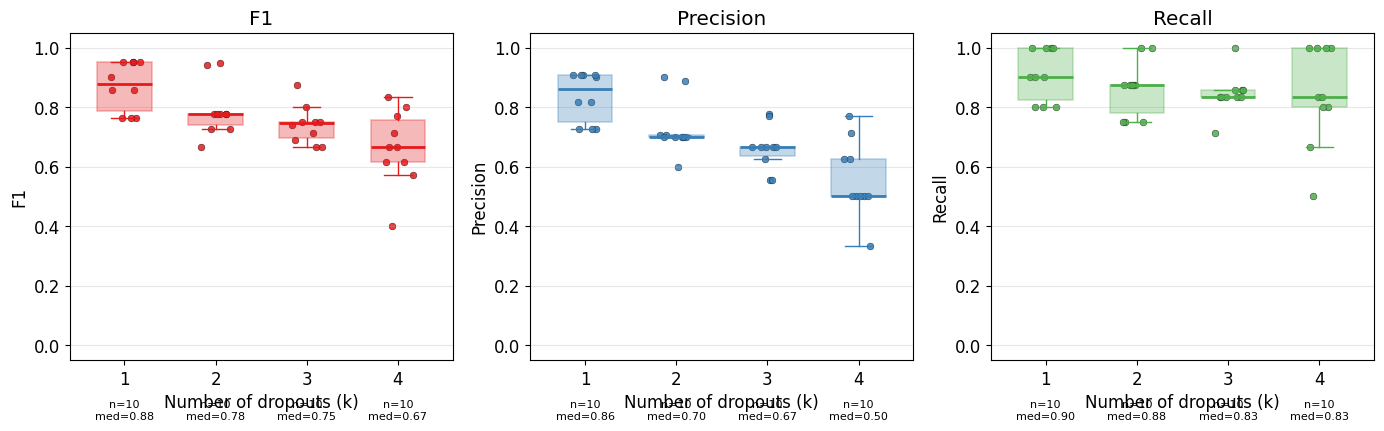

In [5]:
# ---------------------------
# 1) Load all CSVs into one DF
# ---------------------------
BASE = './Out_removal_particles'
K_TO_LOAD = [1, 2, 3, 4]  # adjust if needed

frames = []
for k in K_TO_LOAD:
    path = os.path.join(BASE, f'false_negative_sampled_removing_{k}_particles.csv')
    if not os.path.exists(path):
        print(f"[skip] {path} not found"); continue
    dfk = pd.read_csv(path)
    if 'k' not in dfk.columns:
        dfk['k'] = k  # inject k if not saved in CSV
    frames.append(dfk)

if not frames:
    raise FileNotFoundError("No CSVs found for the requested k values.")

data = pd.concat(frames, ignore_index=True)

# make sure the metric columns exist and are numeric
for col in ['precision', 'recall', 'f1']:
    if col not in data.columns:
        raise KeyError(f"Column '{col}' missing in CSVs.")
    data[col] = pd.to_numeric(data[col], errors='coerce')

# ---------------------------
# 2) Box + jitter by k
# ---------------------------
ORDER_K = sorted(data['k'].unique())
jitter  = 0.18
rng     = np.random.default_rng(42)  # reproducible jitter

metrics = [
    ('f1',        '#e41a1c', 'F1'),
    ('precision', '#377eb8', 'Precision'),
    ('recall',    '#4daf4a', 'Recall'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.25)

for ax, (metric, color, label) in zip(axes, metrics):
    for k in ORDER_K:
        ys = data.loc[data['k'] == k, metric].dropna().to_numpy(float)
        if ys.size == 0:
            continue

        # box
        ax.boxplot(
            ys, positions=[k], widths=0.6, showfliers=False, patch_artist=True,
            boxprops    = dict(facecolor=color, edgecolor=color, linewidth=1.2, alpha=.3),
            medianprops = dict(color=color, linewidth=2),
            whiskerprops= dict(color=color),
            capprops    = dict(color=color),
        )

        # jittered points
        xs = k + rng.uniform(-jitter, jitter, size=ys.size)
        ax.scatter(xs, ys, s=24, color=color, edgecolor='k', linewidth=0.3, alpha=0.85)

        # annotate n and median under each box
        txt = f"n={ys.size}\nmed={np.median(ys):.2f}"
        ax.text(k, -0.12, txt, ha='center', va='top',
                transform=ax.get_xaxis_transform(), fontsize=8)

    ax.set_title(label)
    ax.set_xlabel('Number of dropouts (k)')
    ax.set_ylabel(label)
    ax.set_xticks(ORDER_K)
    ax.set_ylim(-.05, 1.05)
    ax.set_xlim(min(ORDER_K) - 0.6, max(ORDER_K) + 0.6)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#fig.savefig("/Users/sergiocruz/Desktop/VisualProteomics/Papers/Chromatin_3D_Remodeling_Upon_T-Cell_Activation/Revisions/Figures/SI_Removing_particles.pdf", format="pdf", bbox_inches="tight") 